# Лабораторная работа 5

## Вариант 10

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Часть 1

## Задание 1
Реализовать алгоритм k-means для кластеризации на языке Python без использования библиотеки sklearn. Для измерения расстояний использовать метрику Евклида.

In [3]:
def kmeans_from_scratch(X, k, max_iter=100, n_runs=3, seed=None):
    best_centroids = None
    best_labels = None
    best_inertia = np.inf
    run_inertias = []
    
    for run in range(n_runs):
        if seed is not None:
            np.random.seed(seed + run)
            
        idx = np.random.choice(X.shape[0], k, replace=False)
        centroids = X[idx].copy()
        
        for _ in range(max_iter):
            dists = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
            labels = np.argmin(dists, axis=1)
            
            new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
            if np.allclose(centroids, new_centroids):
                break
            centroids = new_centroids
            
        inertia = sum(np.sum((X[labels == j] - centroids[j])**2) for j in range(k))
        run_inertias.append(inertia)
        
        if inertia < best_inertia:
            best_inertia = inertia
            best_centroids = centroids
            best_labels = labels
            
    return best_centroids, best_labels, best_inertia, run_inertias


## Задание 2
Проверить работу алгоритма на контрольном примере из презентации лекции. Сравнить полученные результаты.

Best inertia for k=2: 5.333333333333334
Centroids:
[[4.66666667 4.        ]
 [1.         0.33333333]]

Best inertia for k=3: 3.666666666666667
Centroids:
[[1.5        0.5       ]
 [0.         0.        ]
 [4.66666667 4.        ]]

Best inertia for k=4: 2.0
Centroids:
[[5.  3. ]
 [1.5 0.5]
 [0.  0. ]
 [4.5 4.5]]



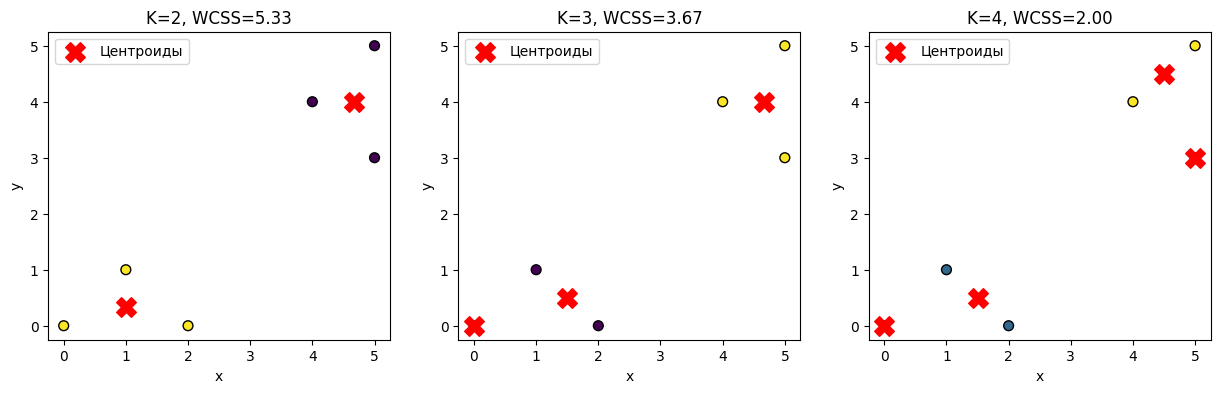

In [5]:
# Пример кластеризации данных методом k-means:
# Элементы начальной выборки: x1 = (1,1) x2 = (0,0) x3 = (2,0) x4 = (4,4) x5 = (5,5) x6 = (5,3)

x = [[1,1], [0,0] , [2,0], [4,4], [5,5], [5,3]]
X = np.array(x)
k = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n_clusters in k:
    centroids, labels, inertia, run_inertias = kmeans_from_scratch(X, n_clusters, seed=42)
    print(f"Best inertia for k={n_clusters}: {inertia}")
    print(f"Centroids:\n{centroids}\n")
    ax = axes[n_clusters-2]
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
    ax.set_title(f'K={n_clusters}, WCSS={inertia:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

Результаты совпадают.

## Задание 3

Применить ваш алгоритм к двумерным данным из индивидуального варианта (Таблица 1).

Лучшая инерция k=2: 25.6
Центроиды:
[[1.6 1.8]
 [4.8 3.2]]

Лучшая инерция k=3: 14.333333333333334
Центроиды:
[[5.66666667 2.33333333]
 [1.6        1.8       ]
 [3.5        4.5       ]]

Лучшая инерция k=4: 6.0
Центроиды:
[[2.5        0.5       ]
 [5.66666667 2.33333333]
 [3.5        4.5       ]
 [1.         2.66666667]]

Лучшая инерция k=5: 5.166666666666666
Центроиды:
[[1.         2.66666667]
 [6.         3.        ]
 [3.5        4.5       ]
 [5.5        2.        ]
 [2.5        0.5       ]]

Лучшая инерция k=6: 3.0
Центроиды:
[[6.  2.5]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.5 0.5]]

Лучшая инерция k=7: 2.5
Центроиды:
[[6.  2. ]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.5 0.5]
 [6.  3. ]]

Лучшая инерция k=8: 1.5
Центроиды:
[[6.  2. ]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.  0. ]
 [6.  3. ]
 [3.  1. ]]

Лучшая инерция k=9: 1.0
Центроиды:
[[6.  2. ]
 [1.  3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.  0. ]
 [6.  3. ]
 [3.  1. ]
 [2.  3. ]]



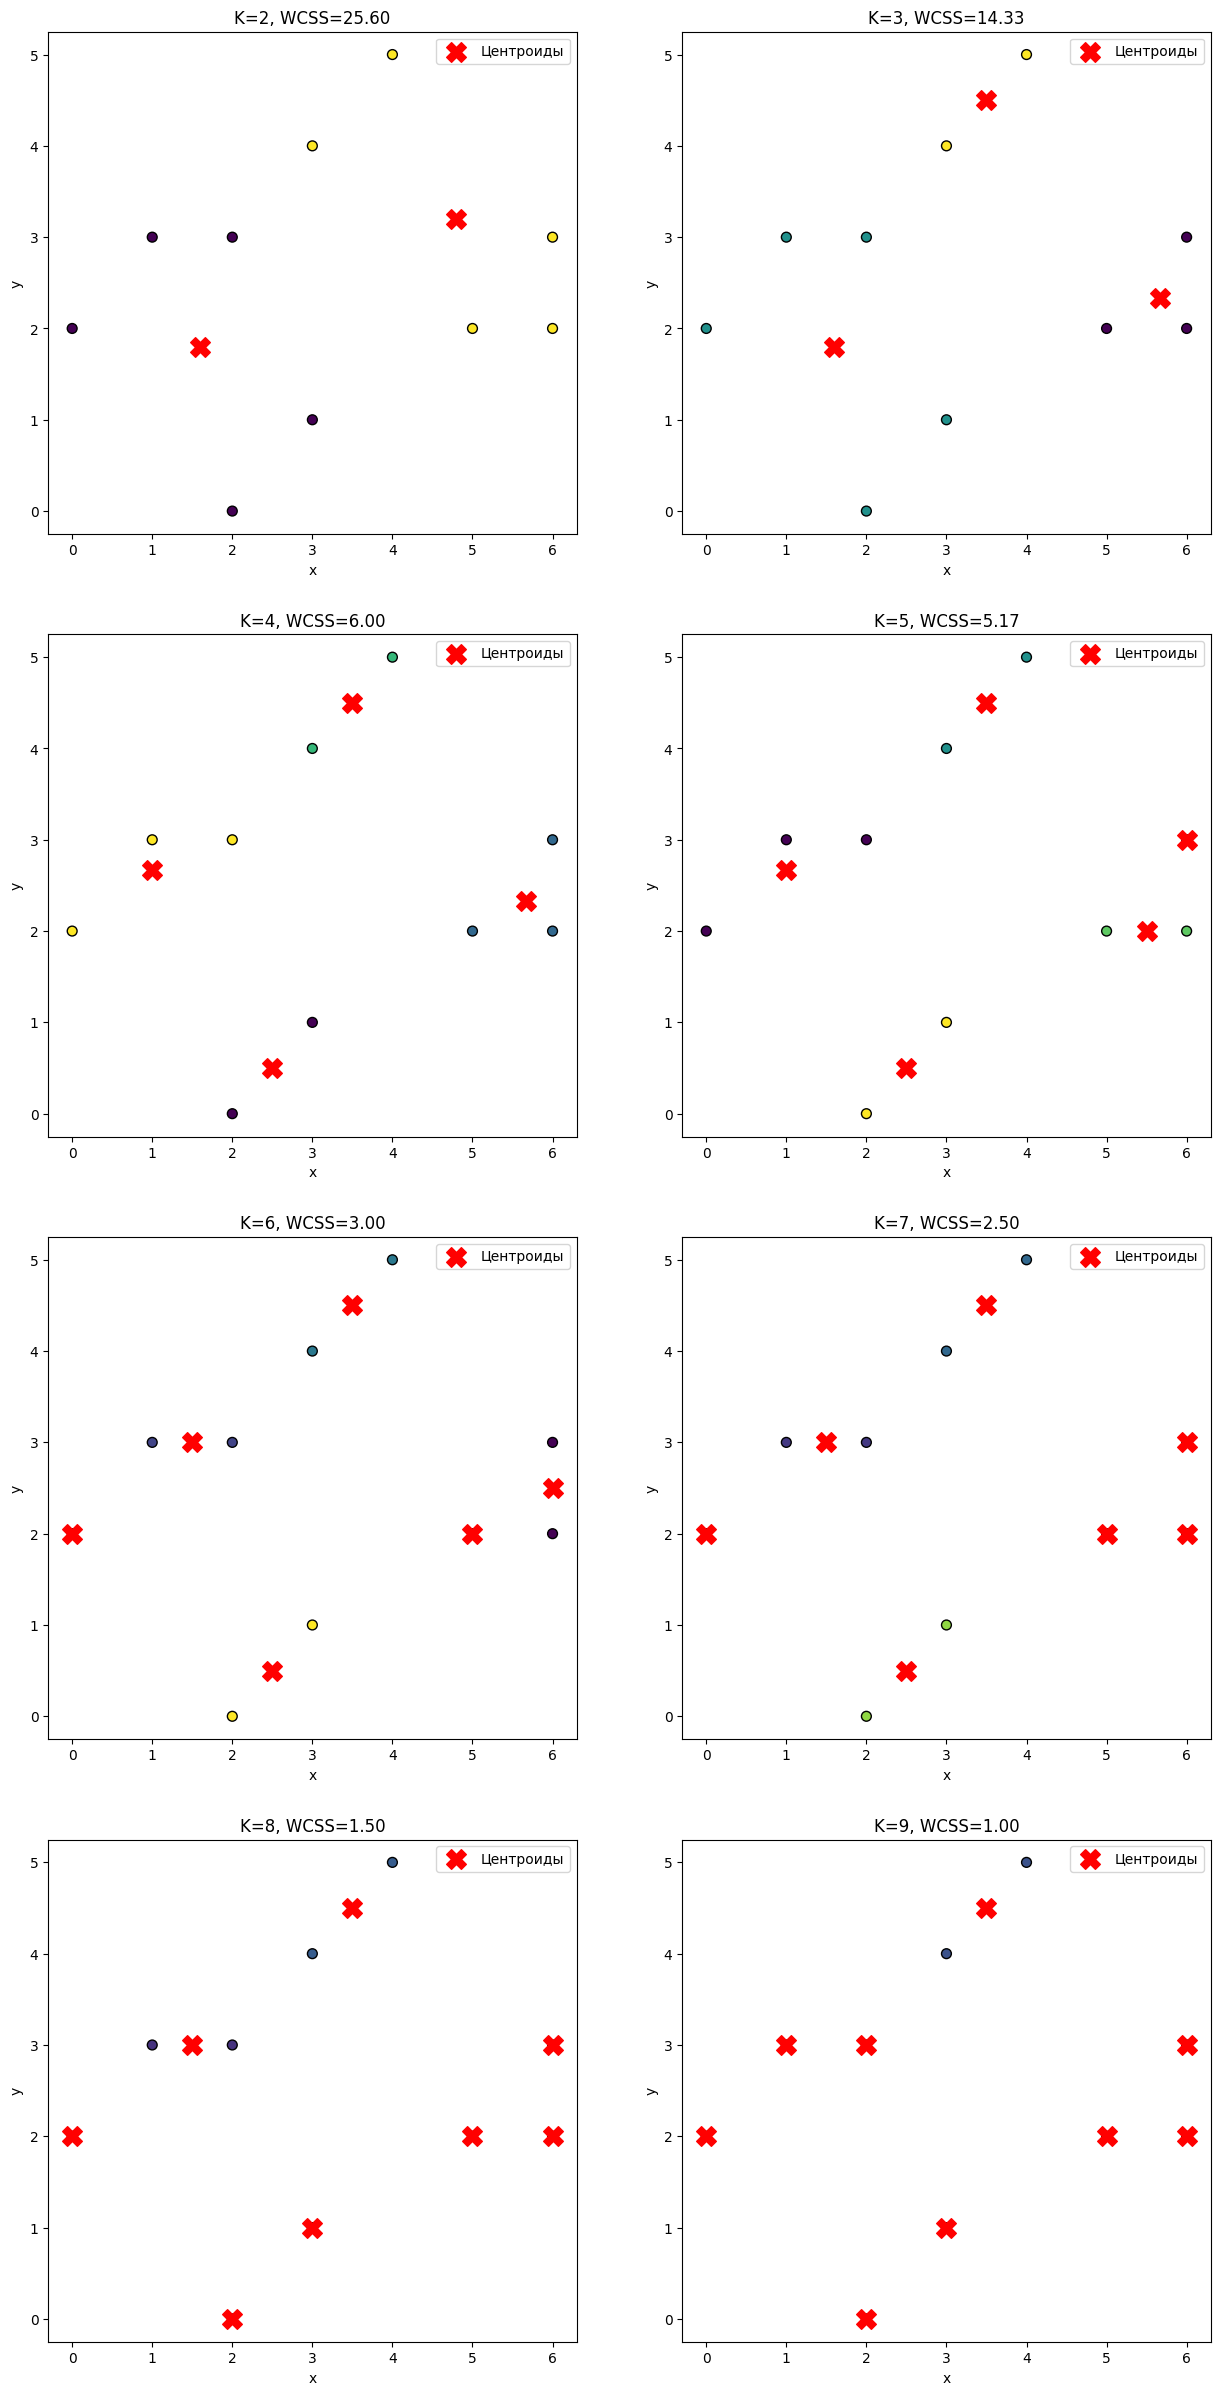

In [15]:
X =  {'x': [0,1,2,2,3,3,4,5,6,6], 'y': [2,3,0,3,1,4,5,2,2,3]}
X = np.array(list(X.values())).T

k = [_ for _ in range(2, 10)]
fig, axes = plt.subplots(4, 2, figsize=(15, 30))
wcss = []
for n_clusters in k:
    centroids, labels, inertia, run_inertias = kmeans_from_scratch(X, n_clusters, seed=42)
    print(f"Лучшая инерция k={n_clusters}: {inertia}")
    print(f"Центроиды:\n{centroids}\n")
    wcss.append([n_clusters, inertia])
    ax = axes[(n_clusters-2)//2, (n_clusters-2)%2]
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
    ax.set_title(f'K={n_clusters}, WCSS={inertia:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

## Задание 4

Реализовать случайную инициализацию центров кластеров.\
 Произвести 2-3 независимых запуска для каждого разделения,\
  чтобы показать влияние начальных условий на итоговый результат.\
  ### уже реализовано

## Задание 5
Провести разделение выборки по индивидуальному варианту на 2, \
а затем на 3 и 4 кластера. Отобразить результаты на диаграмме рассеяния (scatter).\
### см задание 3

## Задание 6
Рассчитать значение внутрикластерного расстояния (сумма квадратов ошибок) \
для каждой конфигурации и выбрать наилучшую.

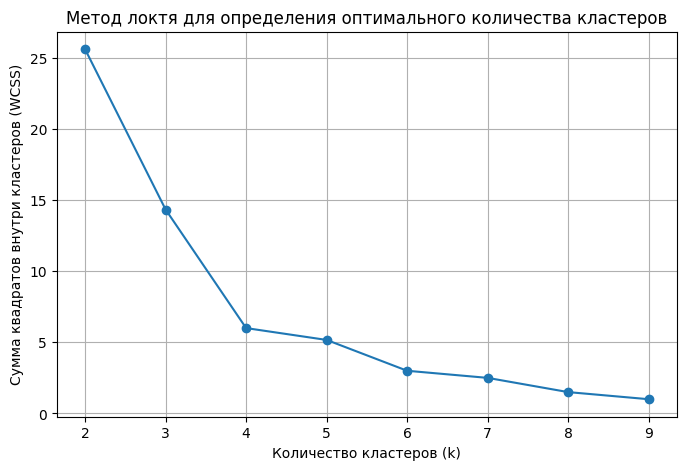

In [17]:
plt.figure(figsize=(8, 5))
wcss = np.array(wcss)
plt.plot(wcss[:, 0], wcss[:, 1], marker='o')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов внутри кластеров (WCSS)')
plt.xticks(k)
plt.grid()
plt.show()

### Изменение переменных выходит на плато при k = 4

# Часть 2

## Задание 7